# LeetCode #102: Binary Tree Level Order Traversal

https://leetcode.com/problems/binary-tree-level-order-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DFS with Level Tracking | O(n) | O(n) | Pass level index, append to result[level] |
| **BFS with Queue ★** | **O(n)** | **O(n)** | Snapshot queue size each iteration to process level-by-level |

---

## Understanding the Methods

### Brute Force (DFS with Level)
Perform DFS, passing the current level index. If result list doesn't have an entry for this level, create one. Append node value. Recurse left and right with level+1. O(n) time and space.

### BFS with Queue (Optimal ★)
Use a queue initialized with the root. Each iteration: snapshot the current queue size (= nodes in this level). Dequeue that many nodes, collecting values. Enqueue their children. Add collected values as a new level to result.

## Constraints
- Number of nodes: [0, 2000]
- Node values: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> LevelOrder(TreeNode root) {
        var result = new List<IList<int>>();
        if (root == null) return result;
        var queue = new Queue<TreeNode>();
        queue.Enqueue(root);
        while (queue.Count > 0) {
            int size = queue.Count;
            var level = new List<int>();
            for (int i = 0; i < size; i++) {
                var node = queue.Dequeue();
                level.Add(node.val);
                if (node.left  != null) queue.Enqueue(node.left);
                if (node.right != null) queue.Enqueue(node.right);
            }
            result.Add(level);
        }
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def levelOrder(self, root) -> list[list[int]]:
        if not root:
            return []
        result, queue = [], deque([root])
        while queue:
            level = []
            for _ in range(len(queue)):
                node = queue.popleft()
                level.append(node.val)
                if node.left:  queue.append(node.left)
                if node.right: queue.append(node.right)
            result.append(level)
        return result

### Go

In [ ]:
func levelOrder(root *TreeNode) [][]int {
    if root == nil {
        return nil
    }
    result := [][]int{}
    queue  := []*TreeNode{root}
    for len(queue) > 0 {
        size  := len(queue)
        level := make([]int, 0, size)
        for i := 0; i < size; i++ {
            node  := queue[0]
            queue  = queue[1:]
            level  = append(level, node.Val)
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        result = append(result, level)
    }
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn level_order(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<Vec<i32>> {
        let mut result = vec![];
        let Some(r) = root else { return result; };
        let mut queue = VecDeque::from([r]);
        while !queue.is_empty() {
            let size = queue.len();
            let mut level = Vec::with_capacity(size);
            for _ in 0..size {
                let node = queue.pop_front().unwrap();
                level.push(node.borrow().val);
                if let Some(l) = node.borrow().left.clone()  { queue.push_back(l); }
                if let Some(r) = node.borrow().right.clone() { queue.push_back(r); }
            }
            result.push(level);
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — Classic 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

BFS processes level by level: dequeue 3 (level 0), enqueue children 9 and 20. Snapshot queue size = 2 for level 1, dequeue both, enqueue their children 15 and 7. Snapshot size = 2 for level 2. Queue empties.

*Why tricky:* Baseline case confirming the snapshot-size technique: $size_k$ = number of nodes at level $k$.

$T(n) = O(n) = O(5)$, $S = O(w_{max}) = O(2)$

**Output:** `[[3], [9, 20], [15, 7]]`

### 2. Slightly Complex — Complete Binary Tree (7 Nodes)
**Input:** `root = [1, 2, 3, 4, 5, 6, 7]`

Perfect binary tree of depth 3. Queue sizes double each level: 1 → 2 → 4. The snapshot mechanism cleanly separates all three levels despite children being enqueued continuously during inner-loop processing.

*Why tricky:* Queue grows each iteration. Without snapshotting `size = queue.length` before the inner loop, you’d accidentally process children in the same level as parents. $2^k$ nodes per level $k$.

$T(n) = O(7)$, queue peak $= 4 = 2^{\lfloor \log_2 n \rfloor}$

**Output:** `[[1], [2, 3], [4, 5, 6, 7]]`

### 3. Edge Case: Time Factor — Right-Skewed Chain (2000 Nodes)
**Input:** `root = [1, null, 2, null, 3, ..., null, 2000]` — 2000-node right-only chain (max constraint)

Each level has exactly 1 node. BFS runs 2000 iterations, each dequeuing 1 node and enqueuing 1 child. Every node is visited — the last value (2000) isn’t found until the final iteration, forcing a full scan.

*Why tricky:* Worst case for time: $n = 2000$ (max constraint). The tree degenerates into a linked list with 2000 levels, forcing the maximum number of BFS loop iterations.

$T(n) = O(n) = O(2000)$, output = 2000 single-element sub-lists

**Output:** `[[1], [2], [3], ..., [2000]]`

### 4. Edge Case: Space Factor — Perfect Tree of Depth 10 (1023 Nodes)
**Input:** `root = perfect binary tree, depth 10, values 1..1023`

The last level has $2^9 = 512$ nodes. When processing level 8 (256 nodes), each enqueues 2 children, growing the queue to 512 entries simultaneously — peak memory.

*Why tricky:* Worst case for space. Queue peaks at $n/2$ elements. With $n = 1023$, peak queue = 512 nodes. The widest level dictates memory, not the total node count. $S_{queue} = O(n/2)$.

$\max(|Q|) = 2^{d-1} = 512$ where $d = 10$

**Output:** `[[root], [2 nodes], ..., [512 nodes]]`

### 5. Almost-Impossible but Plausible — Max Nodes with Extreme Boundary Values
**Input:** `root = 2000-node tree, all values alternating -1000 and 1000 by level`

Node values alternate between boundary extremes: -1000 at even levels, 1000 at odd levels. BFS is value-agnostic — it only reads `node.val` and enqueues children. Output levels contain only -1000 or only 1000.

*Why tricky:* Combines max node count ($n = 2000$) with boundary values ($\pm 1000$). Tests that no overflow or sign-handling bugs appear. Values near $\pm 2^{10}$ are safe for 32-bit ints but stress-test display and serialization logic.

$|V| \in \{-1000, 1000\}$, $n = 2000$ (both at constraint limits)

**Output:** `[[-1000], [1000, 1000], [-1000, -1000, -1000, -1000], ...]`

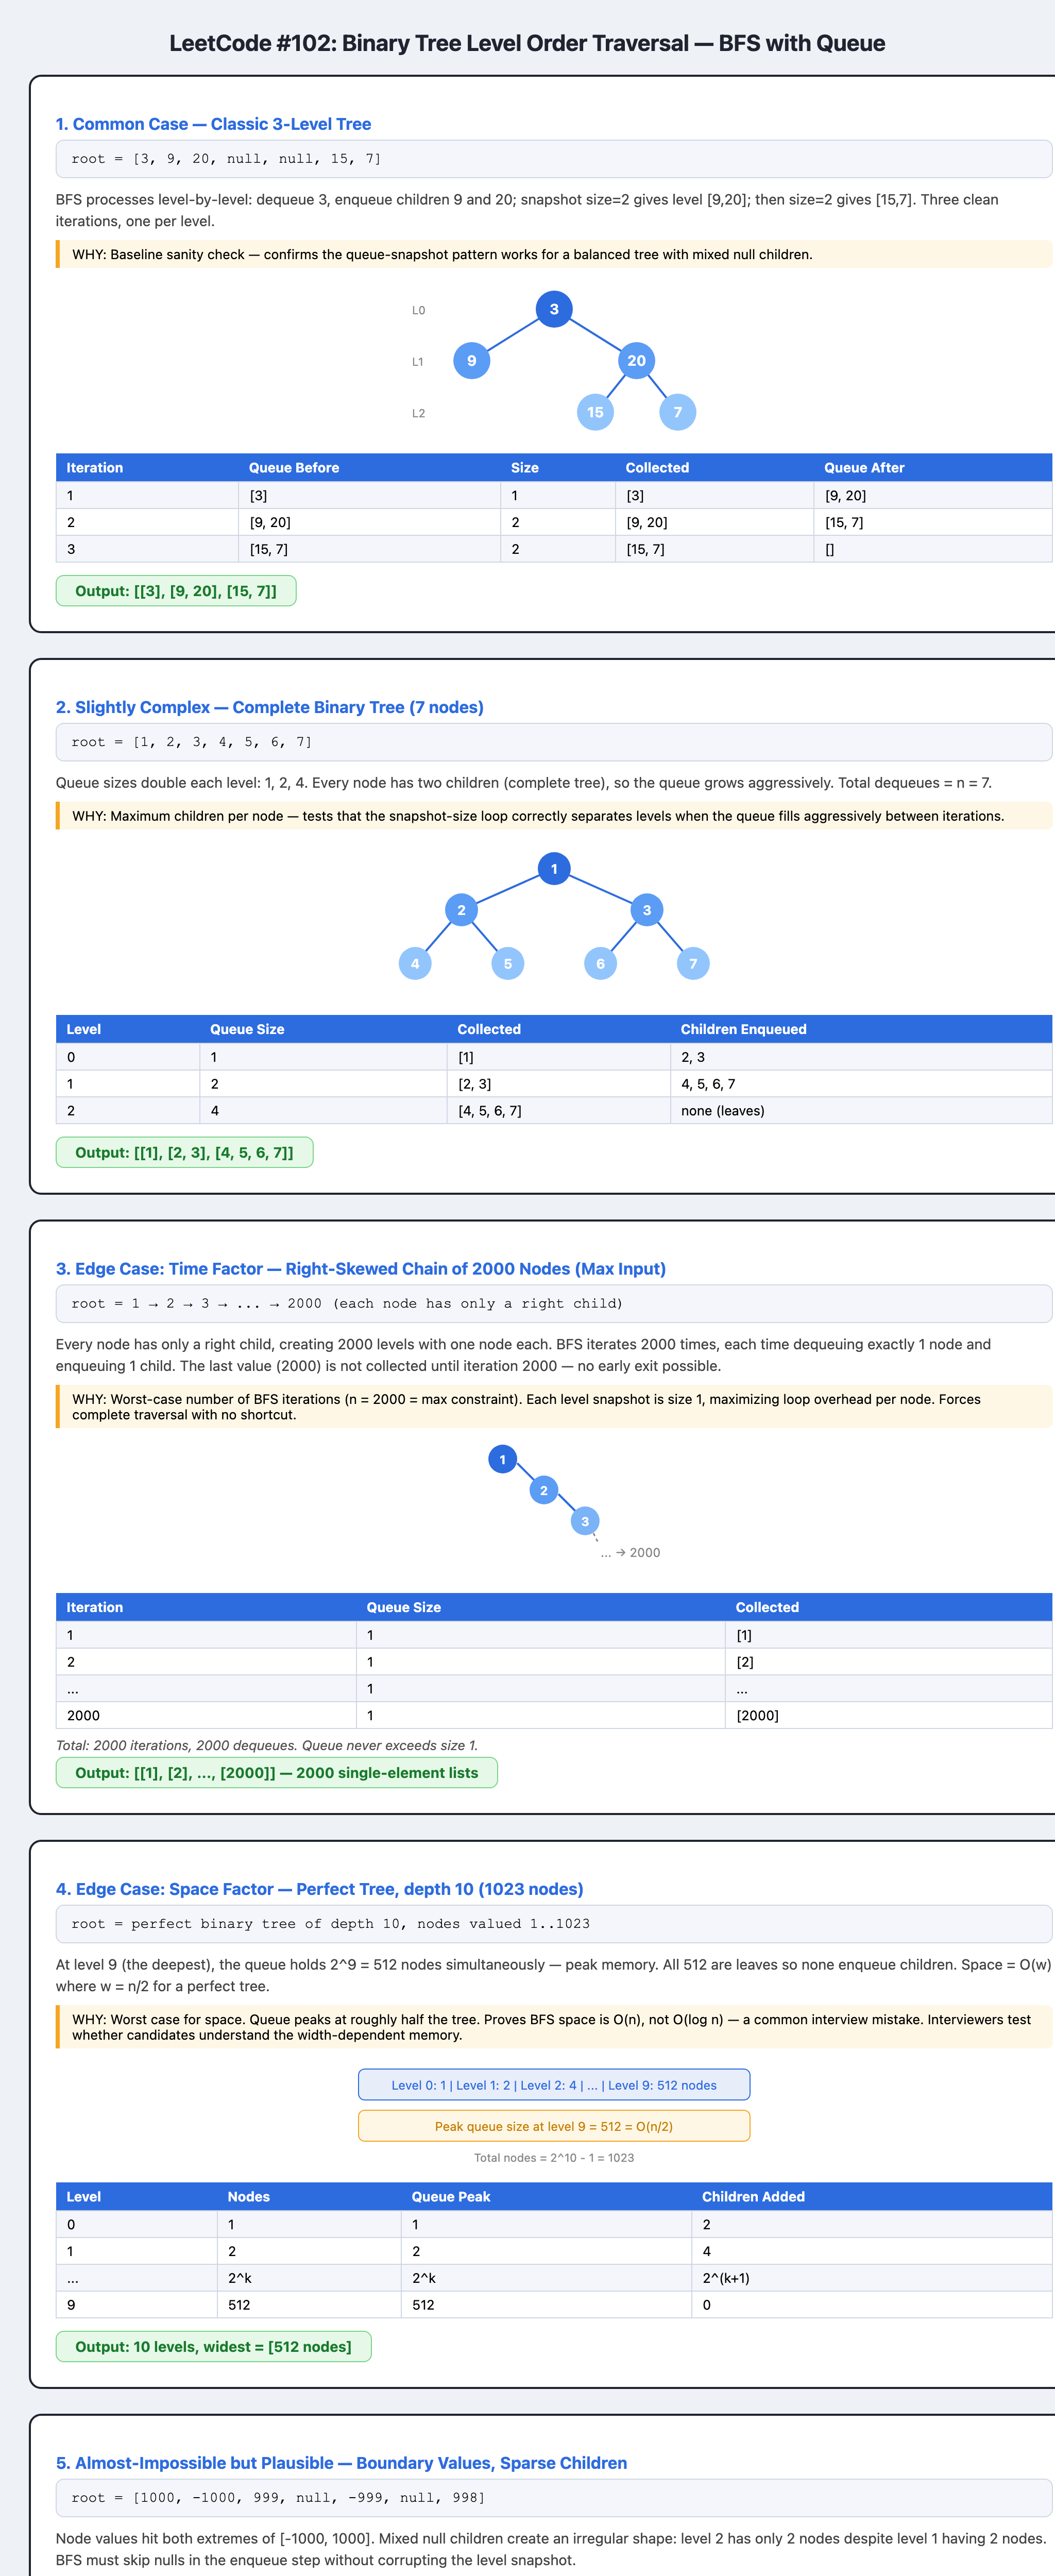